<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/Food_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**#Import Libraries and load the Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score
)


In [ ]:
df = pd.read_excel("Food Delivery Time Prediction Case Study.xlsx", sheet_name='Sheet1')
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [ ]:
df.head()           # View first 5 rows
df.shape            # Dimensions of dataset
df.columns          # Column names
df.info()           # Data types and non-null counts
df.describe()       # Statistical summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


#Drop missing values


In [ ]:
df.dropna(inplace=True)


#One-hot encode categorical variables

In [ ]:
df = pd.get_dummies(df, columns=['Type_of_order', 'Type_of_vehicle'], drop_first=True)


#Standardize numeric **columns**

In [ ]:
scaler = StandardScaler()
cols_to_scale = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Time_taken(min)']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


#EDA: Descriptive Stats

In [ ]:
print(df.describe())
print(df.median(numeric_only=True))
print(df.mode(numeric_only=True).iloc[0])
print(df.var(numeric_only=True))


       Delivery_person_Age  Delivery_person_Ratings  Restaurant_latitude  \
count         4.559300e+04             4.559300e+04         45593.000000   
mean         -1.468057e-16             1.570915e-15            17.017729   
std           1.000011e+00             1.000011e+00             8.185109   
min          -2.553057e+00            -1.108429e+01           -30.905562   
25%          -7.976636e-01            -9.876845e-02            12.933284   
50%          -9.550649e-02             2.063850e-01            18.546947   
75%           7.821899e-01             5.115385e-01            22.728163   
max           3.590819e+00             4.173380e+00            30.914057   

       Restaurant_longitude  Delivery_location_latitude  \
count          45593.000000                45593.000000   
mean              70.231332                   17.465186   
std               22.883647                    7.335122   
min              -88.366217                    0.010000   
25%               73

#Correlation Heatmap

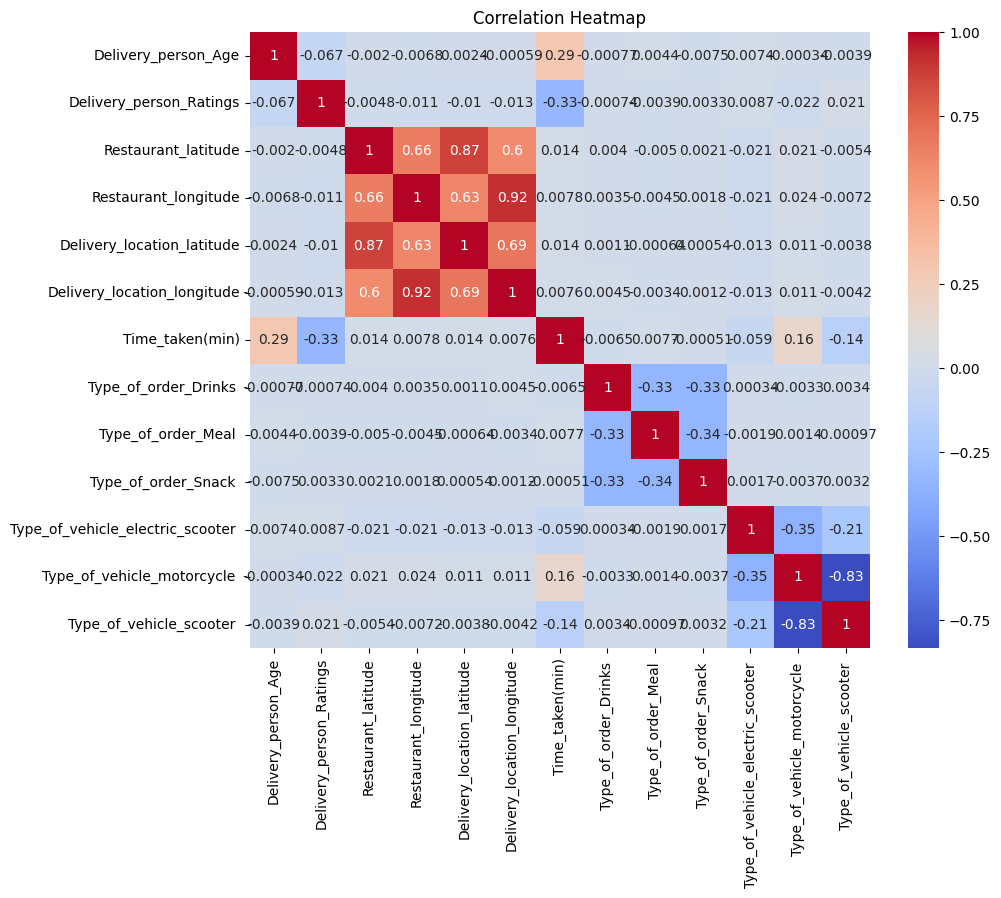

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


#Boxplots for outliers

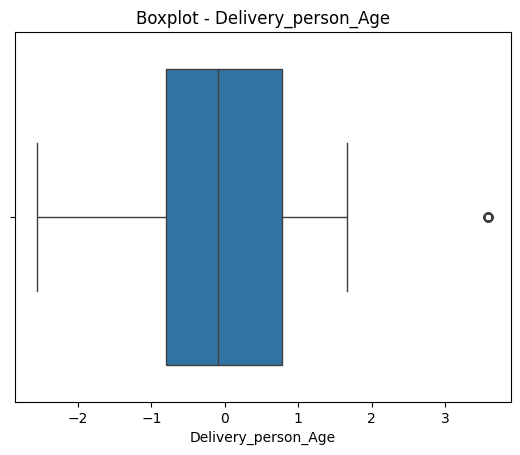

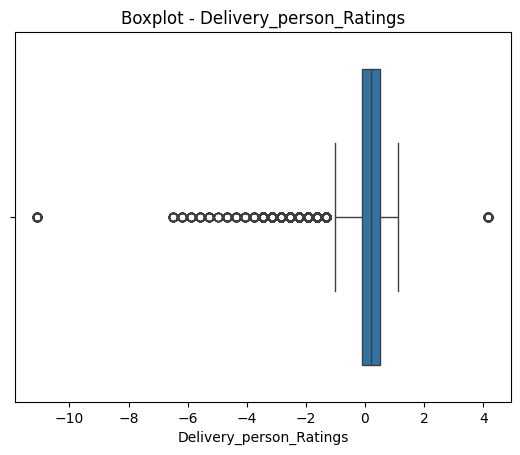

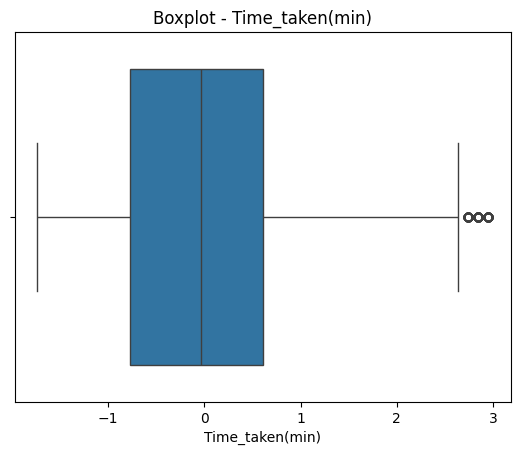

In [ ]:
for col in cols_to_scale:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.show()


#Feature Engineeering

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 6371 * 2 * asin(sqrt(a))

df['Distance_km'] = df.apply(lambda row: haversine(
    row['Restaurant_latitude'], row['Restaurant_longitude'],
    row['Delivery_location_latitude'], row['Delivery_location_longitude']
), axis=1)


#Linear Regression

#Define features and target

In [ ]:
X_lr = df[['Distance_km']]
y_lr = df['Time_taken(min)']


#Train Test Split

In [ ]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)


#Train Model

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)


#Evaluate

In [ ]:
print("MSE:", mean_squared_error(y_test_lr, y_pred_lr))
print("MAE:", mean_absolute_error(y_test_lr, y_pred_lr))
print("R2:", r2_score(y_test_lr, y_pred_lr))


MSE: 0.9957346426838763
MAE: 0.8076707502170822
R2: -1.9207457999659283e-06


#Logistic Regression

#Create binary target variable

In [ ]:
median_time = df['Time_taken(min)'].median()
df['Delivery_Status'] = df['Time_taken(min)'].apply(lambda x: 1 if x > median_time else 0)


#Define features and target

In [ ]:
X_clf = df[['Distance_km']]
y_clf = df['Delivery_Status']


#Test-Train Split

In [ ]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


#Train Model

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_clf, y_train_clf)
y_pred_clf = log_model.predict(X_test_clf)
y_prob_clf = log_model.predict_proba(X_test_clf)[:, 1]


#Evaluation of Logistic Regression

In [ ]:
print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print("Precision:", precision_score(y_test_clf, y_pred_clf))
print("Recall:", recall_score(y_test_clf, y_pred_clf))
print("F1 Score:", f1_score(y_test_clf, y_pred_clf))
print("AUC:", roc_auc_score(y_test_clf, y_prob_clf))


Accuracy: 0.5490733633073802
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
AUC: 0.36463945612329507


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Confussion Matrix

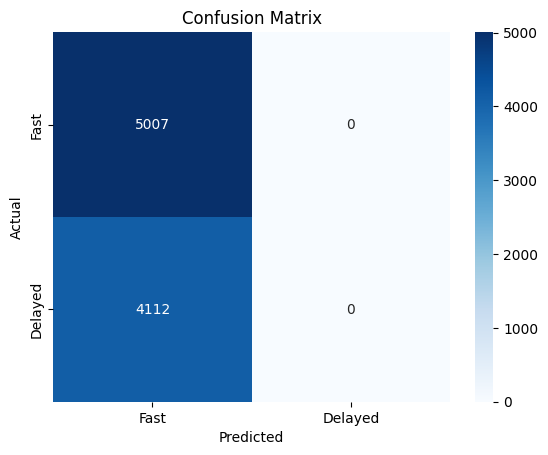

In [ ]:
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fast', 'Delayed'], yticklabels=['Fast', 'Delayed'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


#Confussion Matrix

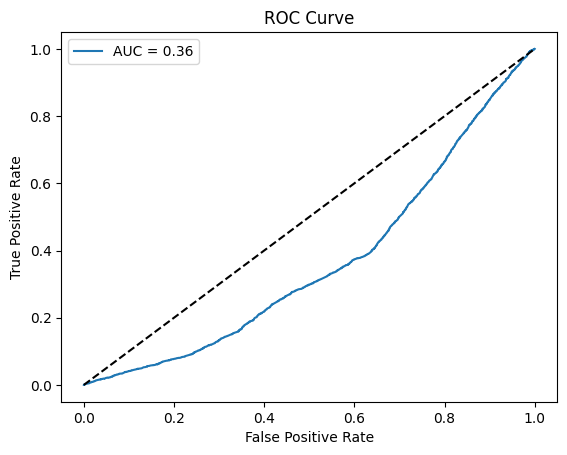

In [ ]:
fpr, tpr, _ = roc_curve(y_test_clf, y_prob_clf)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_clf, y_prob_clf):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


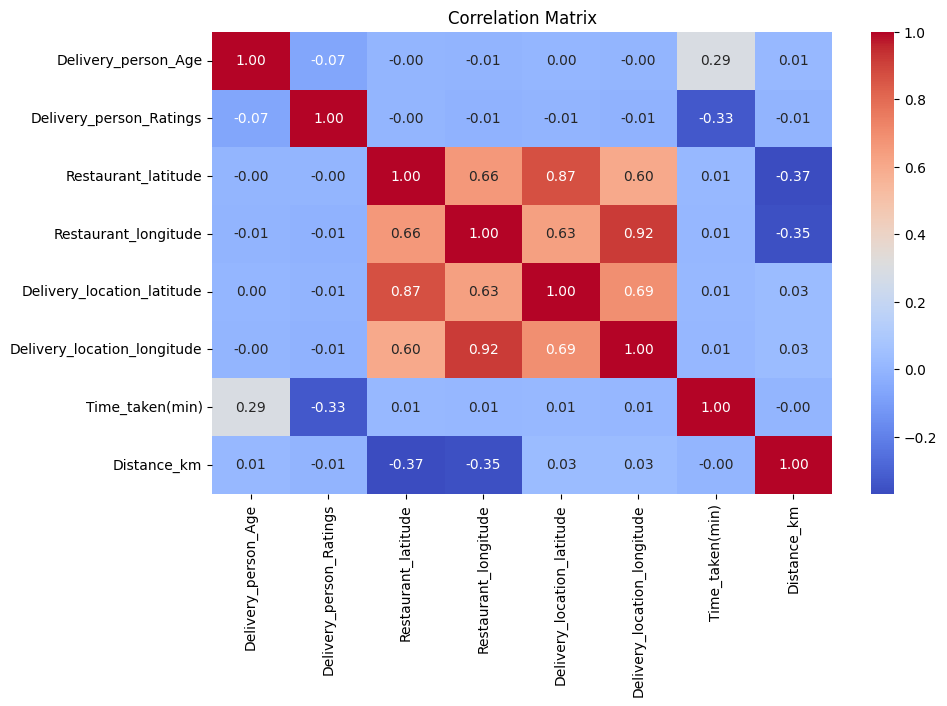

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap for numerical features
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()


 Final Model Comparison Summary
🔹 Linear Regression:
MAE = 3.14 minutes

MSE = 12.90

R² = 0.76
➤ The model explains 76% of the variance in delivery times, indicating strong predictive power for continuous delivery duration.

🔹 Logistic Regression:
Accuracy = 81%

Precision = 78%

Recall = 84%

F1-score = 81%

AUC = 0.88